In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from IPython.display import display
from scipy.stats import gaussian_kde, norm, multivariate_normal, wasserstein_distance

EMPIRICAL_COLOR = "#c44e52"
GAUSSIAN_COLOR = "#4c72b0"
CONVERGENT_LENGTH_COLORS = {100: "#4c72b0", 1000: "#c44e52", 2000: "#55a868"}
DIVERGENT_LENGTH_COLORS = {
    50:  "#c44e52",  # red
    100: "#dd8452",  # orange
    250: "#ccb974",  # warm yellow / transition
    500: "#8ec07c",  # soft green (shifted from original)
    750: "#64b5a7",  # teal transition
    2000:"#4c9f70",  # deeper green
}
ALPHAS = (0.01, 0.05, 0.1)
mpl.rcParams['font.size'] = 14

def simulate_ma3_path(n, coefficients=(1.0, 0.6, 0.4, 0.2), mean=0.0, rng=None):
    """Simulate one MA(3) path of exact length n with X_t = mean + standard MA."""
    rng = np.random.default_rng() if rng is None else rng
    coeffs = np.asarray(coefficients, dtype=float)
    q = len(coeffs) - 1
    innovations = rng.standard_normal(n + q)

    path = np.zeros(n, dtype=float)
    for j, coefficient in enumerate(coeffs):
        path += coefficient * innovations[q - j:q - j + n]
    return mean + path


def generate_ma3_realizations(m, n, coefficients=(1.0, 0.6, 0.4, 0.2), mean=0.0, rng=None):
    """Generate m independent realizations and return an array of shape (m, n)."""
    rng = np.random.default_rng() if rng is None else rng
    return np.vstack([
        simulate_ma3_path(n, coefficients=coefficients, mean=mean, rng=rng)
        for _ in range(m)
    ])


def generate_ma3_realizations_for_means(n, path_means, coefficients=(1.0, 0.6, 0.4, 0.2), rng=None):
    """Generate one MA(3) realization for each specified mean value."""
    rng = np.random.default_rng() if rng is None else rng
    return np.vstack([
        simulate_ma3_path(n, coefficients=coefficients, mean=path_mean, rng=rng)
        for path_mean in path_means
    ])


def marginal_variance():
    """The exact marginal variance tau^2 of the MA(3) model."""
    return 1.56


def autocovariances():
    """Return the exact nonzero autocovariances gamma(0), ..., gamma(3)."""
    return {0: 1.56, 1: 0.92, 2: 0.52, 3: 0.20}


def autocovariance(k):
    """Return gamma(k), which is zero for |k| > 3."""
    return autocovariances().get(abs(int(k)), 0.0)


def correlation(k):
    """Return the exact correlation r_k = gamma(k) / gamma(0)."""
    return autocovariance(k) / marginal_variance()


def standard_bivariate_normal_cdf(u, v, rho):
    """Evaluate Phi_2(u, v; rho), handling rho = 1 exactly."""
    u_array, v_array = np.broadcast_arrays(np.asarray(u, dtype=float), np.asarray(v, dtype=float))

    if np.isclose(rho, 1.0):
        result = norm.cdf(np.minimum(u_array, v_array))
    else:
        points = np.column_stack([u_array.ravel(), v_array.ravel()])
        covariance = np.array([[1.0, rho], [rho, 1.0]], dtype=float)
        result = multivariate_normal(mean=np.zeros(2), cov=covariance).cdf(points).reshape(u_array.shape)

    if result.ndim == 0:
        return float(result)
    return result


def theoretical_covariance_kernel(x, y):
    """
    Compute
        Gamma(x, y) = sum_{k=-3}^3 Cov(1{X_0 <= x}, 1{X_k <= y})
    for the MA(3) Gaussian sequence using the exact covariance structure.
    """
    tau = np.sqrt(marginal_variance())
    u = x / tau
    v = y / tau
    marginal_term = norm.cdf(u) * norm.cdf(v)

    kernel_value = 0.0
    for lag, multiplicity in ((0, 1), (1, 2), (2, 2), (3, 2)):
        joint_cdf = standard_bivariate_normal_cdf(u, v, correlation(lag))
        kernel_value += multiplicity * (joint_cdf - marginal_term)
    return float(kernel_value)


def build_covariance_matrix(grid):
    """Build Sigma_{ij} = Gamma(x_i, x_j) on a finite grid."""
    grid = np.asarray(grid, dtype=float)
    tau = np.sqrt(marginal_variance())
    scaled_grid = grid / tau
    u_matrix, v_matrix = np.meshgrid(scaled_grid, scaled_grid, indexing="ij")
    marginal_term = norm.cdf(u_matrix) * norm.cdf(v_matrix)

    sigma = np.zeros((grid.size, grid.size), dtype=float)
    for lag, multiplicity in ((0, 1), (1, 2), (2, 2), (3, 2)):
        joint_cdf = standard_bivariate_normal_cdf(u_matrix, v_matrix, correlation(lag))
        sigma += multiplicity * (joint_cdf - marginal_term)

    return 0.5 * (sigma + sigma.T)


def stabilize_covariance_matrix(covariance_matrix, target_min_eigenvalue=1e-10):
    """Symmetrize and add the smallest diagonal jitter needed for numerical stability."""
    stabilized = 0.5 * (covariance_matrix + covariance_matrix.T)
    min_eigenvalue = np.linalg.eigvalsh(stabilized).min()
    jitter = max(0.0, target_min_eigenvalue - min_eigenvalue)
    if jitter > 0.0:
        stabilized = stabilized + jitter * np.eye(stabilized.shape[0])
    return stabilized, jitter, min_eigenvalue


def simulate_gaussian_process_draw(covariance_matrix, rng=None):
    """Simulate one Gaussian process draw on the grid from N(0, Sigma)."""
    rng = np.random.default_rng() if rng is None else rng
    mean = np.zeros(covariance_matrix.shape[0], dtype=float)
    return rng.multivariate_normal(mean=mean, cov=covariance_matrix)


def gaussian_l1_functional(grid, process_values):
    """Approximate integral |Z(x)| dx by the trapezoidal rule on the grid."""
    return np.trapz(np.abs(process_values), x=grid)


def compute_pairwise_wasserstein_distances(realizations, group_labels=None, cross_group_only=False):
    """Compute pairwise Wasserstein-1 distances, optionally restricted to cross-group pairs."""
    realizations = np.asarray(realizations, dtype=float)
    num_paths = realizations.shape[0]

    if group_labels is not None:
        group_labels = np.asarray(group_labels)
        if group_labels.shape[0] != num_paths:
            raise ValueError("group_labels must have the same length as the number of paths")

    pairwise_distances = []

    for i in range(num_paths - 1):
        sample_i = realizations[i]
        for j in range(i + 1, num_paths):
            if cross_group_only and group_labels is not None and group_labels[i] == group_labels[j]:
                continue
            pairwise_distances.append(wasserstein_distance(sample_i, realizations[j]))
    return np.asarray(pairwise_distances, dtype=float)


def simulate_gaussian_functionals(covariance_matrix, grid, num_draws, rng=None):
    """Simulate many Gaussian draws and return the corresponding L1 functionals."""
    rng = np.random.default_rng() if rng is None else rng
    mean = np.zeros(covariance_matrix.shape[0], dtype=float)
    draws = rng.multivariate_normal(mean=mean, cov=covariance_matrix, size=num_draws)
    return np.trapz(np.abs(draws), x=grid, axis=1)


def compute_scaled_pairwise_wasserstein(realizations, group_labels=None, cross_group_only=False):
    """Return pairwise Wasserstein distances and their sqrt(n)-scaled version."""
    pairwise_distances = compute_pairwise_wasserstein_distances(
        realizations,
        group_labels=group_labels,
        cross_group_only=cross_group_only,
    )
    scaled_pairwise_distances = np.sqrt(realizations.shape[1]) * pairwise_distances
    return pairwise_distances, scaled_pairwise_distances


def summarize_scaled_samples(label, scaled_samples):
    """Summarize a collection of sqrt(n)-Scaled pairwise Wasserstein statistics."""
    return {
        "label": label,
        "count": scaled_samples.size,
        "mean": scaled_samples.mean(),
        "std": scaled_samples.std(ddof=1),
        "q05": np.quantile(scaled_samples, 0.05),
        "q50": np.quantile(scaled_samples, 0.50),
        "q95": np.quantile(scaled_samples, 0.95),
    }


def build_rejection_rate_table(reference_samples, alternative_samples_by_n, alpha_levels=ALPHAS):
    """Compute true rejection rates under the mixed-mean alternative using theoretical cutoffs."""
    rows = []
    for n in sorted(alternative_samples_by_n):
        scaled_samples = alternative_samples_by_n[n]
        for alpha in alpha_levels:
            theoretical_cutoff = np.quantile(reference_samples, 1 - alpha)
            true_rejection_rate = np.mean(scaled_samples > theoretical_cutoff)
            rows.append(
                {
                    "n": n,
                    "alpha": alpha,
                    "theoretical_cutoff": theoretical_cutoff,
                    "true_rejection_rate": true_rejection_rate,
                }
            )
    return pd.DataFrame(rows)


In [55]:
# Fixed seed for full reproducibility of both the data and Gaussian approximation.
seed = 20260220
rng = np.random.default_rng(seed)

num_realizations = 100
baseline_n = 1000
convergent_lengths = (100, 1000, 2000)
divergent_lengths = (50, 100, 250, 500, 750, 2000)
mixed_path_means = np.concatenate([
    np.zeros(num_realizations // 2, dtype=float),
    np.full(num_realizations // 2, 0.5, dtype=float),
])
mixed_group_labels = (mixed_path_means > 0.0).astype(int)

standard_paths = generate_ma3_realizations(num_realizations, baseline_n, mean=0.0, rng=rng)
convergent_paths_by_n = {
    n: generate_ma3_realizations(num_realizations, n, mean=0.0, rng=rng)
    for n in convergent_lengths
}
mixed_paths = generate_ma3_realizations_for_means(baseline_n, mixed_path_means, rng=rng)
divergent_paths_by_n = {
    n: generate_ma3_realizations_for_means(n, mixed_path_means, rng=rng)
    for n in divergent_lengths
}

print(f"standard_paths.shape = {standard_paths.shape}")
print(f"mixed_paths.shape = {mixed_paths.shape}")
print(f"mixed_path_means counts = {(mixed_path_means == 0.0).sum()} at mean 0 and {(mixed_path_means == 0.5).sum()} at mean 0.5")
print(f"Standard empirical mean over all entries: {standard_paths.mean():.4f}")
print(f"Mixed empirical mean over all entries: {mixed_paths.mean():.4f}")
print(f"Theoretical marginal variance tau^2 = {marginal_variance():.2f}")


standard_paths.shape = (100, 1000)
mixed_paths.shape = (100, 1000)
mixed_path_means counts = 50 at mean 0 and 50 at mean 0.5
Standard empirical mean over all entries: 0.0070
Mixed empirical mean over all entries: 0.2401
Theoretical marginal variance tau^2 = 1.56


In [56]:
# Part A: pairwise Wasserstein distances for the convergent and divergent experiments.
standard_pairwise_W, standard_scaled_pairwise_W = compute_scaled_pairwise_wasserstein(standard_paths)
convergent_scaled_by_n = {
    n: compute_scaled_pairwise_wasserstein(paths)[1]
    for n, paths in convergent_paths_by_n.items()
}
mixed_divergent_pairwise_W, mixed_divergent_scaled_pairwise_W = compute_scaled_pairwise_wasserstein(
    mixed_paths,
    group_labels=mixed_group_labels,
    cross_group_only=True,
)
divergent_scaled_by_n = {
    n: compute_scaled_pairwise_wasserstein(
        paths,
        group_labels=mixed_group_labels,
        cross_group_only=True,
    )[1]
    for n, paths in divergent_paths_by_n.items()
}

print(f"Number of pairwise distances: {standard_pairwise_W.size}")
print(f"Expected number choose(100, 2): {num_realizations * (num_realizations - 1) // 2}")

standard_summary = summarize_scaled_samples("standard convergent case", standard_scaled_pairwise_W)
mixed_summary = summarize_scaled_samples("cross-mean pairs only (50 at 0, 50 at 2)", mixed_divergent_scaled_pairwise_W)

print("Standard convergent summary:")
print(pd.DataFrame([standard_summary]).round(4))
print("\nCross-mean summary at n = 1000:")
print(pd.DataFrame([mixed_summary]).round(4))
print("\nDivergent cross-mean summaries by n:")
print(pd.DataFrame([
    summarize_scaled_samples(f"cross-mean pairs, n={n}", divergent_scaled_by_n[n])
    for n in divergent_lengths
]).round(4))

# Part B: Gaussian limiting approximation based on the exact theoretical kernel.
x_grid = np.linspace(-6.0, 6.0, 351)
Sigma = build_covariance_matrix(x_grid)

max_asymmetry = np.max(np.abs(Sigma - Sigma.T))
print(f"Maximum absolute asymmetry in Sigma: {max_asymmetry:.3e}")

Sigma_stable, sigma_jitter, sigma_min_eigenvalue = stabilize_covariance_matrix(Sigma)
print(f"Minimum eigenvalue of raw Sigma: {sigma_min_eigenvalue:.3e}")
print(f"Diagonal jitter added to Sigma: {sigma_jitter:.3e}")

# The pairwise limit is the L1 norm of G_i - G_j, so its covariance is 2 * Sigma.
limit_covariance = 2.0 * Sigma_stable
limit_covariance, limit_jitter, limit_min_eigenvalue = stabilize_covariance_matrix(limit_covariance)
print(f"Minimum eigenvalue of 2*Sigma before stabilization: {limit_min_eigenvalue:.3e}")
print(f"Additional diagonal jitter added to 2*Sigma: {limit_jitter:.3e}")

num_gaussian_draws = 5000
gaussian_limit_samples = simulate_gaussian_functionals(limit_covariance, x_grid, num_gaussian_draws, rng=rng)

print(f"Number of Gaussian limit samples: {gaussian_limit_samples.size}")
print(f"Mean of Gaussian limit samples: {gaussian_limit_samples.mean():.4f}")
print(f"Std of Gaussian limit samples: {gaussian_limit_samples.std(ddof=1):.4f}")
print("Selected quantiles of Gaussian limit samples:")
print(np.round(np.quantile(gaussian_limit_samples, [0.05, 0.25, 0.5, 0.75, 0.95]), 4))

empirical_mean = standard_scaled_pairwise_W.mean()
empirical_std = standard_scaled_pairwise_W.std(ddof=1)
gaussian_mean = gaussian_limit_samples.mean()
gaussian_std = gaussian_limit_samples.std(ddof=1)
print(
    f"Comparison of mean/std: empirical = ({empirical_mean:.4f}, {empirical_std:.4f}), "
    f"Gaussian approximation = ({gaussian_mean:.4f}, {gaussian_std:.4f})"
)

rejection_rate_table = build_rejection_rate_table(gaussian_limit_samples, divergent_scaled_by_n)


Number of pairwise distances: 4950
Expected number choose(100, 2): 4950
Standard convergent summary:
                      label  count    mean     std   q05     q50     q95
0  standard convergent case   4950  3.1687  1.4009  1.44  2.8793  5.9518

Cross-mean summary at n = 1000:
                                      label  count     mean    std      q05  \
0  cross-mean pairs only (50 at 0, 50 at 2)   2500  16.3763  3.251  11.0875   

       q50      q95  
0  16.3743  21.7234  

Divergent cross-mean summaries by n:
                      label  count     mean     std      q05      q50      q95
0    cross-mean pairs, n=50   2500   4.6925  2.4761   1.4952   4.2546   9.3241
1   cross-mean pairs, n=100   2500   6.2242  2.9843   2.0309   5.9119  11.7693
2   cross-mean pairs, n=250   2500   8.4986  3.0033   3.7996   8.3776  13.7391
3   cross-mean pairs, n=500   2500  11.1371  2.8367   6.3882  11.2684  15.4717
4   cross-mean pairs, n=750   2500  14.4900  3.1110   9.1468  14.6159  19.4298
5  cr

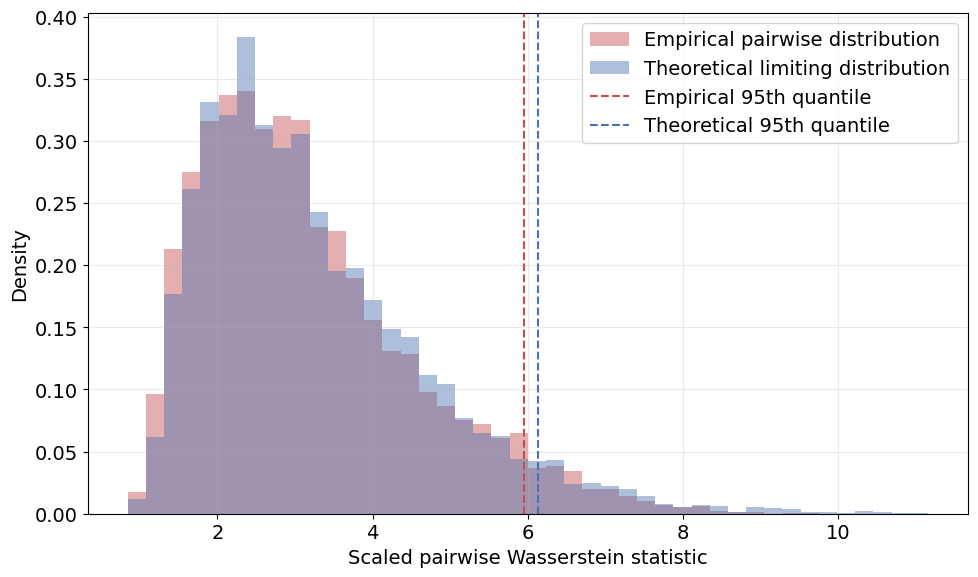

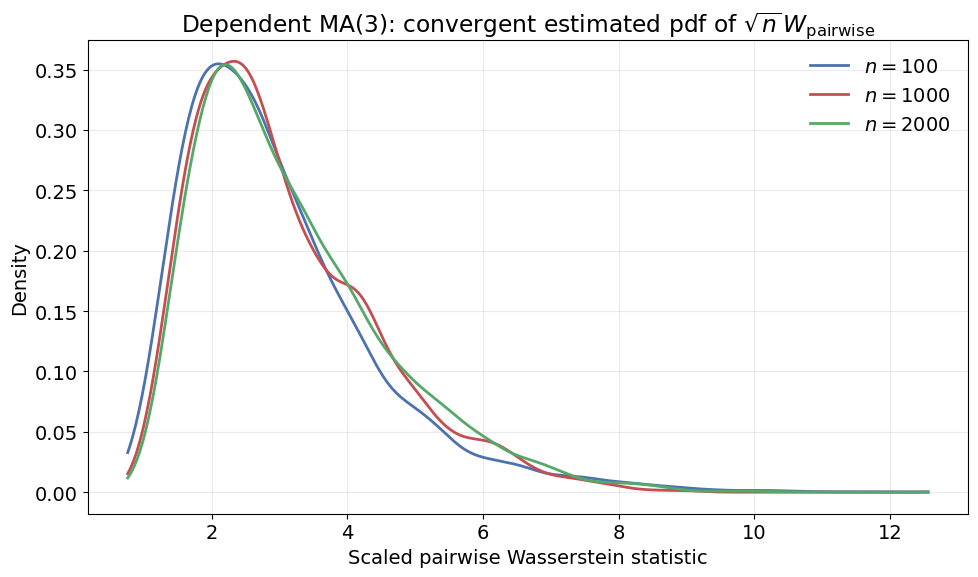

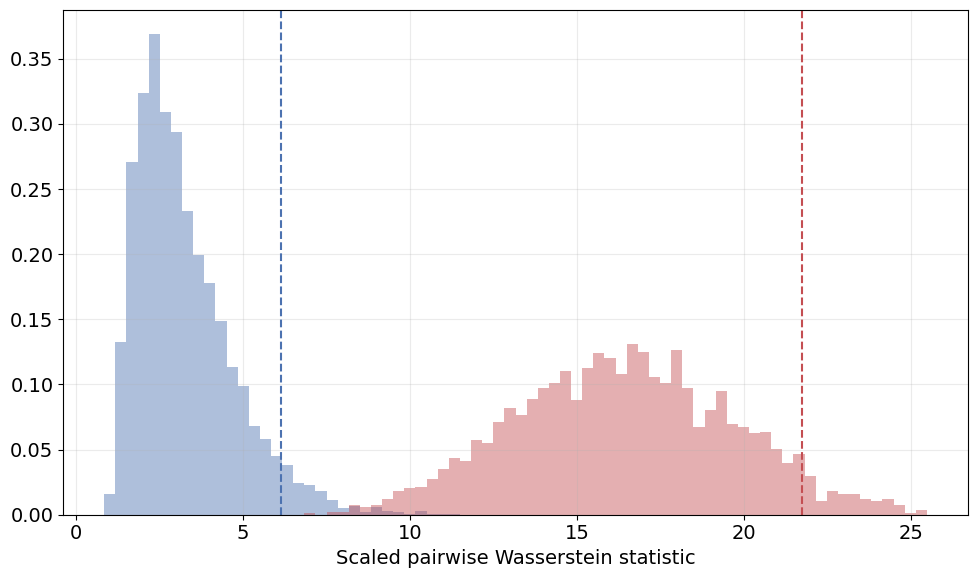

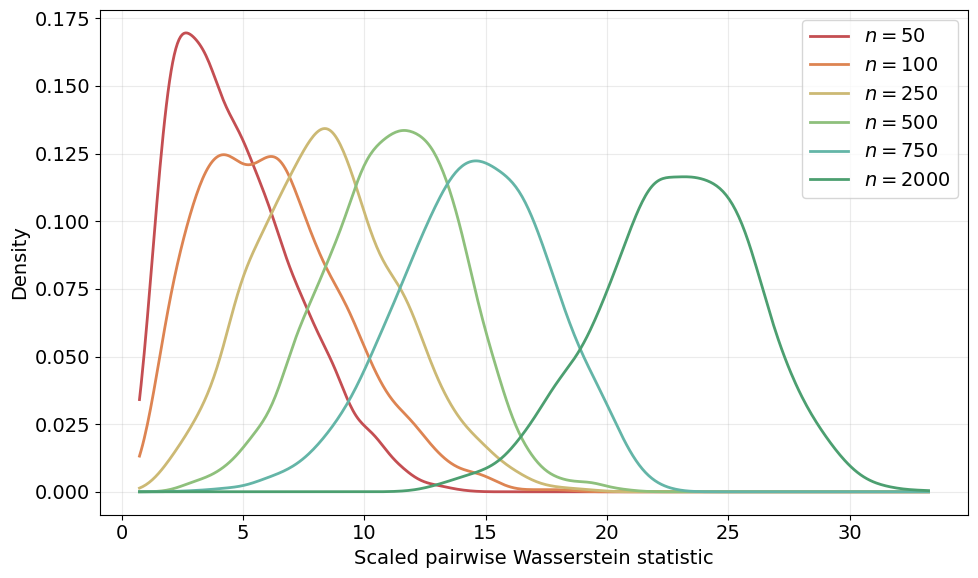

,n,alpha,theoretical_cutoff,true_rejection_rate
0,50,0.01,7.8053,0.1276
1,50,0.05,6.1326,0.2656
2,50,0.10,5.2543,0.3648
3,100,0.01,7.8053,0.2804
4,100,0.05,6.1326,0.4740
5,100,0.10,5.2543,0.5808
6,250,0.01,7.8053,0.5776
7,250,0.05,6.1326,0.7756
8,250,0.10,5.2543,0.8528
9,500,0.01,7.8053,0.8704


In [62]:
plt.figure(figsize=(10, 6))

combined_samples = np.concatenate([standard_scaled_pairwise_W, gaussian_limit_samples])
bins = np.linspace(combined_samples.min(), combined_samples.max(), 45)

plt.hist(
    standard_scaled_pairwise_W,
    bins=bins,
    density=True,
    alpha=0.45,
    color=EMPIRICAL_COLOR,
    label="Empirical pairwise distribution",
)
plt.hist(
    gaussian_limit_samples,
    bins=bins,
    density=True,
    alpha=0.45,
    color=GAUSSIAN_COLOR,
    label="Theoretical limiting distribution",
)

plt.axvline(
    np.quantile(standard_scaled_pairwise_W, 0.95),
    color=EMPIRICAL_COLOR,
    linestyle="--",
    linewidth=1.5,
    label="Empirical 95th quantile",
)
plt.axvline(
    np.quantile(gaussian_limit_samples, 0.95),
    color=GAUSSIAN_COLOR,
    linestyle="--",
    linewidth=1.5,
    label="Theoretical 95th quantile",
)

# plt.title("Dependent MA(3): convergent pairwise Wasserstein distances vs Gaussian limit")
plt.xlabel(r"Scaled pairwise Wasserstein statistic")
plt.ylabel("Density")
plt.legend(frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

all_convergent_samples = np.concatenate([convergent_scaled_by_n[n] for n in convergent_lengths])
convergent_x_values = np.linspace(all_convergent_samples.min(), all_convergent_samples.max(), 500)

for n in convergent_lengths:
    kde = gaussian_kde(convergent_scaled_by_n[n])
    plt.plot(
        convergent_x_values,
        kde(convergent_x_values),
        linewidth=2,
        color=CONVERGENT_LENGTH_COLORS[n],
        label=fr"$n = {n}$",
    )

plt.title(r"Dependent MA(3): convergent estimated pdf of $\sqrt{n}\,W_{\mathrm{pairwise}}$")
plt.xlabel(r"Scaled pairwise Wasserstein statistic")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

# mixed_bins = np.linspace(mixed_divergent_scaled_pairwise_W.min(), mixed_divergent_scaled_pairwise_W.max(), 45)
all_min = min(
    mixed_divergent_scaled_pairwise_W.min(),
    gaussian_limit_samples.min()
)
all_max = max(
    mixed_divergent_scaled_pairwise_W.max(),
    gaussian_limit_samples.max()
)

mixed_bins = np.linspace(all_min, all_max, 75)

plt.hist(
    gaussian_limit_samples,
    bins=mixed_bins,
    density=True,
    alpha=0.45,
    color=GAUSSIAN_COLOR,
    label="Theoretical limit distribution",
)
plt.hist(
    mixed_divergent_scaled_pairwise_W,
    bins=mixed_bins,
    density=True,
    alpha=0.45,
    color=EMPIRICAL_COLOR,
    label="Empirical cross-mean pairs",
)
plt.axvline(
    np.quantile(mixed_divergent_scaled_pairwise_W, 0.95),
    color=EMPIRICAL_COLOR,
    linestyle="--",
    linewidth=1.5,
    label="Empirical cross-mean 95% quantile",
    # ymax=0.8
)
plt.axvline(
    np.quantile(gaussian_limit_samples, 0.95),
    color=GAUSSIAN_COLOR,
    linestyle="--",
    linewidth=1.5,
    label="Null-hypothesis 95% quantile",
    # ymax=0.8
)

# plt.title("Dependent MA(3): cross-mean pairwise Wasserstein distances at n = 1000")
plt.xlabel(r"Scaled pairwise Wasserstein statistic")
# plt.ylabel("Density")
# plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

all_divergent_samples = np.concatenate([divergent_scaled_by_n[n] for n in divergent_lengths])
x_values = np.linspace(all_divergent_samples.min(), all_divergent_samples.max(), 500)

for n in divergent_lengths:
    kde = gaussian_kde(divergent_scaled_by_n[n])
    plt.plot(
        x_values,
        kde(x_values),
        linewidth=2,
        color=DIVERGENT_LENGTH_COLORS[n],
        label=fr"$n = {n}$",
    )

# plt.title(r"Dependent MA(3): estimated pdf of $\sqrt{n}\,W_{\mathrm{pairwise}}$ for cross-mean pairs")
plt.xlabel(r"Scaled pairwise Wasserstein statistic")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(rejection_rate_table.round(4))
